# Incoming/Outgoing Ratio Comparison

This notebook compares `Incoming / Outgoing` ratios using each flowlet's `outgoing` field.

Because the newest snapshot has essentially no usable LLM traffic, this notebook uses:
- `Non-LLM` from the **latest** snapshot at threshold `0.1`
- `LLM` from the **previous** snapshot at threshold `0.1`

It compares the ratio at two levels:
- packet totals
- flowlet counts


In [11]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="crest")


def get_snapshot_dirs() -> list[Path]:
    candidate_roots = [
        Path("data-pipeline/data/snapshots"),
        Path("../data-pipeline/data/snapshots"),
    ]

    for candidate in candidate_roots:
        snapshot_dirs = sorted(candidate.glob("snapshot_*"), reverse=True)
        if snapshot_dirs:
            return snapshot_dirs

    checked = ", ".join(str(path.resolve()) for path in candidate_roots)
    raise FileNotFoundError(f"No snapshots found. Checked: {checked}")


def load_snapshot_subset(snapshot_dir: Path, traffic_class: str, threshold: float) -> pd.DataFrame:
    rows = []
    for fpath in sorted((snapshot_dir / "captures").glob("*.json")):
        with open(fpath, "r", encoding="utf-8") as f:
            doc = json.load(f)

        if doc.get("threshold") != threshold:
            continue

        for fl in doc.get("flowlets") or []:
            if fl.get("traffic_class") != traffic_class:
                continue
            if fl.get("outgoing") not in {True, False}:
                continue

            rows.append({
                "snapshot": snapshot_dir.name,
                "traffic_class": traffic_class,
                "direction": "Outgoing" if fl.get("outgoing") else "Incoming",
                "packet_count": fl.get("packet_count", 0),
                "flowlet_id": fl.get("flowlet_id"),
            })

    return pd.DataFrame(rows)


snapshot_dirs = get_snapshot_dirs()
latest_snapshot = snapshot_dirs[0]
previous_snapshot = snapshot_dirs[1]
THRESHOLD = 0.1

llm_df = load_snapshot_subset(previous_snapshot, "llm", THRESHOLD)
non_llm_df = load_snapshot_subset(latest_snapshot, "non_llm", THRESHOLD)

llm_df["traffic_class_label"] = "LLM"
non_llm_df["traffic_class_label"] = "Non-LLM"
plot_df = pd.concat([llm_df, non_llm_df], ignore_index=True)

source_table = pd.DataFrame([
    {"Traffic class": "LLM", "Snapshot used": previous_snapshot.name, "Threshold": THRESHOLD, "Flowlets": len(llm_df)},
    {"Traffic class": "Non-LLM", "Snapshot used": latest_snapshot.name, "Threshold": THRESHOLD, "Flowlets": len(non_llm_df)},
])

display(source_table.style.hide(axis="index").format({"Threshold": "{:g}", "Flowlets": "{:,.0f}"}).set_caption("Snapshot source used for each traffic class"))

print(f"LLM source snapshot: {previous_snapshot.name}")
print(f"Non-LLM source snapshot: {latest_snapshot.name}")
print(f"Comparison threshold: {THRESHOLD:g} s")
plot_df.head()


Traffic class,Snapshot used,Threshold,Flowlets
LLM,snapshot_20260416_163332,0.1,"104,736"
Non-LLM,snapshot_20260427_114825,0.1,"29,632"


LLM source snapshot: snapshot_20260416_163332
Non-LLM source snapshot: snapshot_20260427_114825
Comparison threshold: 0.1 s


,snapshot,traffic_class,direction,packet_count,flowlet_id,traffic_class_label
0,snapshot_20260416_163332,llm,Outgoing,2,1,LLM
1,snapshot_20260416_163332,llm,Outgoing,2,1,LLM
2,snapshot_20260416_163332,llm,Outgoing,2,1,LLM
3,snapshot_20260416_163332,llm,Outgoing,2,1,LLM
4,snapshot_20260416_163332,llm,Incoming,6,14,LLM


In [12]:
classes = ["LLM", "Non-LLM"]
directions = ["Incoming", "Outgoing"]
full_index = pd.MultiIndex.from_product([classes, directions], names=["traffic_class_label", "direction"])

packet_direction = (
    plot_df.groupby(["traffic_class_label", "direction"])["packet_count"]
    .sum()
    .reindex(full_index, fill_value=0)
    .reset_index()
)

flowlet_direction = (
    plot_df.groupby(["traffic_class_label", "direction"])
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="flowlet_count")
)

packet_summary = packet_direction.pivot(index="traffic_class_label", columns="direction", values="packet_count").fillna(0)
packet_summary["Incoming / Outgoing"] = packet_summary["Incoming"] / packet_summary["Outgoing"].replace(0, pd.NA)
packet_summary["Outgoing share"] = packet_summary["Outgoing"] / (packet_summary["Incoming"] + packet_summary["Outgoing"]).replace(0, pd.NA)

flowlet_summary = flowlet_direction.pivot(index="traffic_class_label", columns="direction", values="flowlet_count").fillna(0)
flowlet_summary["Incoming / Outgoing"] = flowlet_summary["Incoming"] / flowlet_summary["Outgoing"].replace(0, pd.NA)
flowlet_summary["Outgoing share"] = flowlet_summary["Outgoing"] / (flowlet_summary["Incoming"] + flowlet_summary["Outgoing"]).replace(0, pd.NA)

display(packet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Incoming / Outgoing": lambda v: "inf" if pd.isna(v) else f"{v:.3f}",
    "Outgoing share": "{:.1%}",
}).set_caption("Packet totals and Incoming / Outgoing ratio"))

display(flowlet_summary.style.format({
    "Incoming": "{:,.0f}",
    "Outgoing": "{:,.0f}",
    "Incoming / Outgoing": lambda v: "inf" if pd.isna(v) else f"{v:.3f}",
    "Outgoing share": "{:.1%}",
}).set_caption("Flowlet counts and Incoming / Outgoing ratio"))

ratio_plot = pd.DataFrame({
    "traffic_class_label": classes * 2,
    "metric": ["Packet ratio"] * len(classes) + ["Flowlet ratio"] * len(classes),
    "ratio": [packet_summary.loc[c, "Incoming / Outgoing"] for c in classes] + [flowlet_summary.loc[c, "Incoming / Outgoing"] for c in classes],
})


direction,Incoming,Outgoing,Incoming / Outgoing,Outgoing share
traffic_class_label,,,,
LLM,"584,287","1,178,716",0.496,66.9%
Non-LLM,"235,115","632,423",0.372,72.9%


direction,Incoming,Outgoing,Incoming / Outgoing,Outgoing share
traffic_class_label,,,,
LLM,"54,690","50,046",1.093,47.8%
Non-LLM,"8,625","21,007",0.411,70.9%


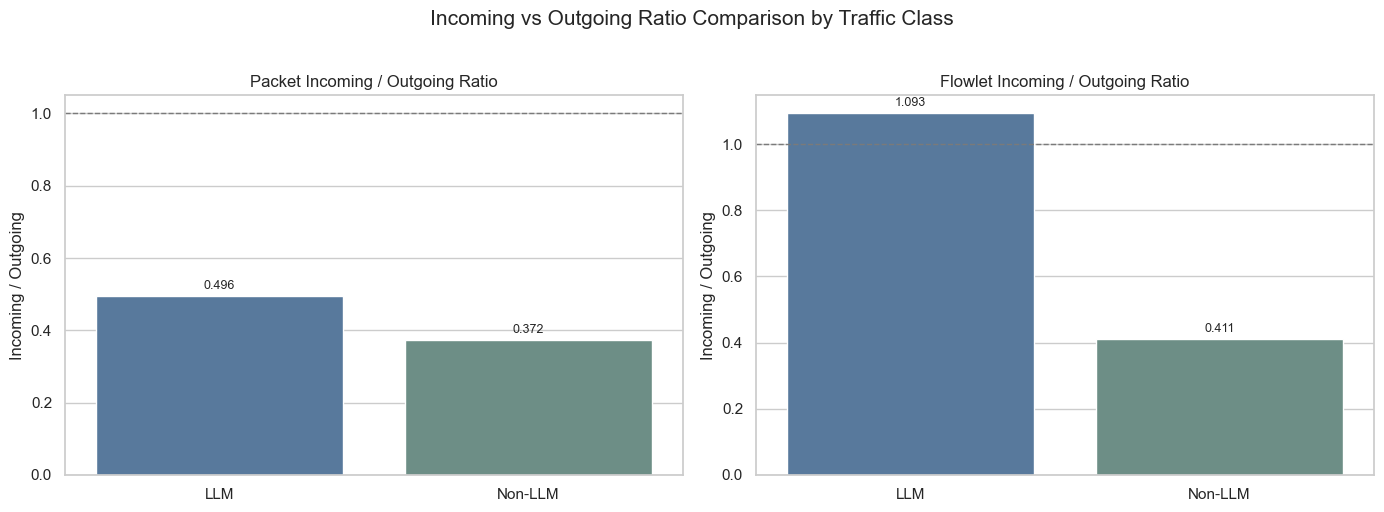

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

plot_order = ["LLM", "Non-LLM"]
palette = ["#4C78A8", "#689389"]

for ax, metric in zip(axes, ["Packet ratio", "Flowlet ratio"]):
    subset = ratio_plot[ratio_plot["metric"] == metric].copy()
    subset["traffic_class_label"] = pd.Categorical(subset["traffic_class_label"], categories=plot_order, ordered=True)
    subset = subset.sort_values("traffic_class_label")

    sns.barplot(
        data=subset,
        x="traffic_class_label",
        y="ratio",
        order=plot_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title(metric.replace("ratio", "Incoming / Outgoing Ratio"))
    ax.set_xlabel("")
    ax.set_ylabel("Incoming / Outgoing")
    ax.axhline(1.0, color="#7A7A7A", linestyle="--", linewidth=1)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

fig.suptitle("Incoming vs Outgoing Ratio Comparison by Traffic Class", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### Notes

- `Incoming / Outgoing < 1` means outgoing traffic dominates.
- `Incoming / Outgoing > 1` means incoming traffic dominates.
- The class comparison mixes snapshots intentionally because the newest snapshot does not contain enough LLM traffic for a meaningful ratio comparison.
